# Wikipedia Gender Representation Analysis - 20th Century Writers

**Research Question:** Do female writers receive systematically different Wikipedia coverage compared to male writers of similar significance?

## Methodology
- **Sample:** 9 women + 9 men writers from Chile, Netherlands, and Greece
- **Control:** Same field (literature), same century (20th), same countries
- **Comparison:** Native language vs. English Wikipedia coverage

---

## 1. Setup & Dependencies

In [1]:
# Install dependencies (run once)
!pip install requests pandas matplotlib seaborn scipy --break-system-packages

In [2]:
# Import libraries
import requests
import json
import re
import time
import pandas as pd
import numpy as np
from datetime import datetime
from scipy import stats

print("Libraries imported successfully")

Libraries imported successfully


## 2. Wikipedia Analyzer Class

In [4]:
class WikipediaAnalyzer:
    def __init__(self):
        self.session = requests.Session()
        self.session.headers.update({'User-Agent': 'WikipediaGenderStudy/1.0 (Research Project)'})
    
    def get_article_data(self, title, lang='en'):
        """Extract complete information from a Wikipedia article"""
        base_url = f"https://{lang}.wikipedia.org/w/api.php"
        
        params = {
            'action': 'query',
            'titles': title,
            'prop': 'revisions|images|links|categories|langlinks|info',
            'rvprop': 'content|size',
            'rvslots': 'main',
            'pllimit': 'max',
            'imlimit': 'max',
            'lllimit': 'max',
            'inprop': 'url',
            'format': 'json',
            'formatversion': 2
        }
        
        try:
            response = self.session.get(base_url, params=params, timeout=30)
            data = response.json()
            page = data['query']['pages'][0]
            
            if 'missing' in page:
                print(f"Article not found: {title} ({lang})")
                return None
            
            content = page['revisions'][0]['slots']['main']['content'] if 'revisions' in page else ''
            analysis = self.analyze_content(content)
            
            return {
                'title': page['title'],
                'lang': lang,
                'url': page['fullurl'],
                'word_count': analysis['word_count'],
                'character_count': analysis['character_count'],
                'image_count': len(page.get('images', [])),
                'reference_count': analysis['reference_count'],
                'internal_links_count': len(page.get('links', [])),
                'section_count': analysis['section_count'],
                'sections': analysis['sections'],
                'infobox_present': analysis['infobox_present'],
                'categories_count': len(page.get('categories', [])),
                'languages_available': len(page.get('langlinks', [])),
            }
        except Exception as e:
            print(f"Error: {e}")
            return None
    
    def analyze_content(self, content):
        """Analyze article content"""
        text = self.remove_wiki_markup(content)
        words = re.findall(r'\b\w+\b', text)
        sections = re.findall(r'^==+\s*(.+?)\s*==+', content, re.MULTILINE)
        references = re.findall(r'<ref[^>]*>.*?</ref>|<ref[^>]*/>', content, re.DOTALL)
        infobox = bool(re.search(r'\{\{Infobox|\{\{Ficha', content, re.IGNORECASE))
        
        return {
            'word_count': len(words),
            'character_count': len(text),
            'section_count': len(sections),
            'sections': sections,
            'reference_count': len(references),
            'infobox_present': infobox,
        }
    
    def remove_wiki_markup(self, content):
        """Remove MediaWiki markup"""
        text = re.sub(r'<ref[^>]*>.*?</ref>', '', content, flags=re.DOTALL)
        text = re.sub(r'<ref[^>]*/>', '', text)
        text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)
        text = re.sub(r'\{\{[^}]+\}\}', '', text)
        text = re.sub(r'\[\[([^|\]]+\|)?([^\]]+)\]\]', r'\2', text)
        text = re.sub(r"'''([^']+)'''", r'\1', text)
        text = re.sub(r"''([^']+)''", r'\1', text)
        return text
    
    def compare_articles(self, title_native, title_english, native_lang, gender, country):
        """Compare article in native language vs English"""
        print(f"Analyzing: {title_native} ({native_lang}) vs {title_english} (en)")
        
        native_data = self.get_article_data(title_native, native_lang)
        english_data = self.get_article_data(title_english, 'en')
        
        if not native_data or not english_data:
            print("Could not retrieve both articles")
            return None
        
        ratio = english_data['word_count'] / native_data['word_count'] if native_data['word_count'] > 0 else 0
        
        print(f"  ✓ Words: {native_data['word_count']:,} (native) vs {english_data['word_count']:,} (EN) | Ratio: {ratio:.2f}x")
        
        return {
            'name': title_native,
            'gender': gender,
            'country': country,
            'native_lang': native_lang,
            'native_data': native_data,
            'english_data': english_data,
            'differences': {
                'word_count_diff': english_data['word_count'] - native_data['word_count'],
                'word_count_ratio': ratio,
                'image_count_diff': english_data['image_count'] - native_data['image_count'],
                'reference_count_diff': english_data['reference_count'] - native_data['reference_count'],
            }
        }

analyzer = WikipediaAnalyzer()
print("Analyzer loaded successfully")

Analyzer loaded successfully


## 3. Define Writers to Analyze

### Sample: 9 Women + 9 Men Writers (20th Century Literature)

In [15]:
# WOMEN WRITERS (20th Century)

WOMEN_WRITERS = [
    # CHILE - Literatura
    ("Gabriela Mistral", "Gabriela Mistral", "es", "Chile"),
    ("Isabel Allende", "Isabel Allende", "es", "Chile"),
    ("Marcela Paz", "Marcela Paz", "es", "Chile"),
    
    # NETHERLANDS - Literatura
    ("Annie M.G. Schmidt", "Annie M.G. Schmidt", "nl", "Netherlands"),
    ("Hella Haasse", "Hella Haasse", "nl", "Netherlands"),
    ("Renate Dorrestein", "Renate Dorrestein", "nl", "Netherlands"),
    
    # GREECE - Literatura
    ("Κική Δημουλά", "Kiki Dimoula", "el", "Greece"),
    ("Κατερίνα Γώγου", "Katerina Gogou", "el", "Greece"),
    ("Κατερίνα Αγγελάκη - Ρουκ", "Katerina Anghelaki-Rooke", "el", "Greece"),
]

# MEN WRITERS (20th Century) - MATCHED BY COUNTRY

MEN_WRITERS = [
    # CHILE - Literatura
    ("Pablo Neruda", "Pablo Neruda", "es", "Chile"),
    ("Roberto Bolaño", "Roberto Bolaño", "es", "Chile"),
    ("José Donoso", "José Donoso", "es", "Chile"),
    
    # NETHERLANDS - Literatura
    ("Harry Mulisch", "Harry Mulisch", "nl", "Netherlands"),
    ("Gerard Reve", "Gerard Reve", "nl", "Netherlands"),
    ("Jan Wolkers", "Jan Wolkers", "nl", "Netherlands"),
    
    # GREECE - Literatura
    ("Ντίνος Χριστιανόπουλος", "Dinos Christianopoulos", "el", "Greece"),  # ← CORREGIDO
    ("Μανόλης Αναγνωστάκης", "Manolis Anagnostakis", "el", "Greece"),
    ("Νίκος Καββαδίας", "Nikos Kavvadias", "el", "Greece"),
]

print(f"Sample configured:")
print(f"- {len(WOMEN_WRITERS)} women writers")
print(f"- {len(MEN_WRITERS)} men writers")
print(f"- Total: {len(WOMEN_WRITERS) + len(MEN_WRITERS)} writers from 3 countries")

Sample configured:
- 9 women writers
- 9 men writers
- Total: 18 writers from 3 countries


## 4. Analyze Women Writers

Collecting data for all 9 women writers...

In [16]:
women_results = []

print("ANALYZING WOMEN WRITERS")

for i, (native_name, english_name, lang_code, country) in enumerate(WOMEN_WRITERS, 1):
    print(f"\n[{i}/{len(WOMEN_WRITERS)}] Country: {country}")
    
    result = analyzer.compare_articles(native_name, english_name, lang_code, "Female", country)
    
    if result:
        women_results.append(result)
    
    if i < len(WOMEN_WRITERS):
        time.sleep(1)

print(f"Women writers analysis complete: {len(women_results)}/{len(WOMEN_WRITERS)} successful")


ANALYZING WOMEN WRITERS

[1/9] Country: Chile
Analyzing: Gabriela Mistral (es) vs Gabriela Mistral (en)
  ✓ Words: 8,050 (native) vs 2,606 (EN) | Ratio: 0.32x

[2/9] Country: Chile
Analyzing: Isabel Allende (es) vs Isabel Allende (en)
  ✓ Words: 2,536 (native) vs 1,821 (EN) | Ratio: 0.72x

[3/9] Country: Chile
Analyzing: Marcela Paz (es) vs Marcela Paz (en)
  ✓ Words: 1,209 (native) vs 556 (EN) | Ratio: 0.46x

[4/9] Country: Netherlands
Analyzing: Annie M.G. Schmidt (nl) vs Annie M.G. Schmidt (en)
  ✓ Words: 2,303 (native) vs 1,184 (EN) | Ratio: 0.51x

[5/9] Country: Netherlands
Analyzing: Hella Haasse (nl) vs Hella Haasse (en)
  ✓ Words: 3,204 (native) vs 1,680 (EN) | Ratio: 0.52x

[6/9] Country: Netherlands
Analyzing: Renate Dorrestein (nl) vs Renate Dorrestein (en)
  ✓ Words: 1,611 (native) vs 281 (EN) | Ratio: 0.17x

[7/9] Country: Greece
Analyzing: Κική Δημουλά (el) vs Kiki Dimoula (en)
  ✓ Words: 1,090 (native) vs 489 (EN) | Ratio: 0.45x

[8/9] Country: Greece
Analyzing: Κατερίνα

## 5. Analyze Men Writers

Collecting data for all 9 men writers...

In [17]:
men_results = []

print("ANALYZING MEN WRITERS")


for i, (native_name, english_name, lang_code, country) in enumerate(MEN_WRITERS, 1):
    print(f"\n[{i}/{len(MEN_WRITERS)}] Country: {country}")
    
    result = analyzer.compare_articles(native_name, english_name, lang_code, "Male", country)
    
    if result:
        men_results.append(result)
    
    if i < len(MEN_WRITERS):
        time.sleep(1)

print(f"Men writers analysis complete: {len(men_results)}/{len(MEN_WRITERS)} successful")

ANALYZING MEN WRITERS

[1/9] Country: Chile
Analyzing: Pablo Neruda (es) vs Pablo Neruda (en)
  ✓ Words: 4,570 (native) vs 5,814 (EN) | Ratio: 1.27x

[2/9] Country: Chile
Analyzing: Roberto Bolaño (es) vs Roberto Bolaño (en)
  ✓ Words: 3,768 (native) vs 4,687 (EN) | Ratio: 1.24x

[3/9] Country: Chile
Analyzing: José Donoso (es) vs José Donoso (en)
  ✓ Words: 2,062 (native) vs 1,872 (EN) | Ratio: 0.91x

[4/9] Country: Netherlands
Analyzing: Harry Mulisch (nl) vs Harry Mulisch (en)
  ✓ Words: 5,665 (native) vs 1,458 (EN) | Ratio: 0.26x

[5/9] Country: Netherlands
Analyzing: Gerard Reve (nl) vs Gerard Reve (en)
  ✓ Words: 4,769 (native) vs 1,427 (EN) | Ratio: 0.30x

[6/9] Country: Netherlands
Analyzing: Jan Wolkers (nl) vs Jan Wolkers (en)
  ✓ Words: 3,384 (native) vs 882 (EN) | Ratio: 0.26x

[7/9] Country: Greece
Analyzing: Ντίνος Χριστιανόπουλος (el) vs Dinos Christianopoulos (en)
  ✓ Words: 1,718 (native) vs 317 (EN) | Ratio: 0.18x

[8/9] Country: Greece
Analyzing: Μανόλης Αναγνωστάκης

## 6. Create Combined DataFrame

In [19]:
# Combine all results
all_results = women_results + men_results

# Create DataFrame
data = []
for r in all_results:
    native = r['native_data']
    english = r['english_data']
    diff = r['differences']
    
    data.append({
        'Name': native['title'],
        'Gender': r['gender'],
        'Country': r['country'],
        'Native_Lang': r['native_lang'],
        'Words_Native': native['word_count'],
        'Words_English': english['word_count'],
        'Ratio_EN_Native': round(diff['word_count_ratio'], 3),
        'Word_Difference': diff['word_count_diff'],
        'Images_Native': native['image_count'],
        'Images_English': english['image_count'],
        'References_Native': native['reference_count'],
        'References_English': english['reference_count'],
        'Sections_Native': native['section_count'],
        'Sections_English': english['section_count'],
        'Internal_Links_Native': native['internal_links_count'],
        'Internal_Links_English': english['internal_links_count'],
        'Languages_Available': native['languages_available'],
        'URL_Native': native['url'],
        'URL_English': english['url'],
    })

df = pd.DataFrame(data)

print("Combined DataFrame created")
print(f"\nDataFrame shape: {df.shape}")
print(f"Women: {len(df[df['Gender'] == 'Female'])}")
print(f"Men: {len(df[df['Gender'] == 'Male'])}")

df.head(18)

Combined DataFrame created

DataFrame shape: (18, 19)
Women: 9
Men: 9


,Name,Gender,Country,Native_Lang,Words_Native,Words_English,Ratio_EN_Native,Word_Difference,Images_Native,Images_English,References_Native,References_English,Sections_Native,Sections_English,Internal_Links_Native,Internal_Links_English,Languages_Available,URL_Native,URL_English
0,Gabriela Mistral,Female,Chile,es,8050,2606,0.324,-5444,27,16,95,28,20,14,307,425,103,https://es.wikipedia.org/wiki/Gabriela_Mistral,https://en.wikipedia.org/wiki/Gabriela_Mistral
1,Isabel Allende,Female,Chile,es,2536,1821,0.718,-715,7,10,47,59,19,17,177,470,72,https://es.wikipedia.org/wiki/Isabel_Allende,https://en.wikipedia.org/wiki/Isabel_Allende
2,Marcela Paz,Female,Chile,es,1209,556,0.460,-653,7,2,18,3,8,5,88,6,6,https://es.wikipedia.org/wiki/Marcela_Paz,https://en.wikipedia.org/wiki/Marcela_Paz
3,Annie M.G. Schmidt,Female,Netherlands,nl,2303,1184,0.514,-1119,11,10,15,26,13,11,183,139,30,https://nl.wikipedia.org/wiki/Annie_M.G._Schmidt,https://en.wikipedia.org/wiki/Annie_M.G._Schmidt
4,Hella Haasse,Female,Netherlands,nl,3204,1680,0.524,-1524,7,8,25,24,22,9,145,50,29,https://nl.wikipedia.org/wiki/Hella_Haasse,https://en.wikipedia.org/wiki/Hella_Haasse
5,Renate Dorrestein,Female,Netherlands,nl,1611,281,0.174,-1330,7,2,38,9,11,3,123,18,21,https://nl.wikipedia.org/wiki/Renate_Dorrestein,https://en.wikipedia.org/wiki/Renate_Dorrestein
6,Κική Δημουλά,Female,Greece,el,1090,489,0.449,-601,6,4,14,8,15,6,61,24,22,https://el.wikipedia.org/wiki/%CE%9A%CE%B9%CE%...,https://en.wikipedia.org/wiki/Kiki_Dimoula
7,Κατερίνα Γώγου,Female,Greece,el,1295,326,0.252,-969,1,3,13,4,16,9,92,29,7,https://el.wikipedia.org/wiki/%CE%9A%CE%B1%CF%...,https://en.wikipedia.org/wiki/Katerina_Gogou
8,Κατερίνα Αγγελάκη - Ρουκ,Female,Greece,el,1107,690,0.623,-417,1,2,6,0,7,4,47,14,4,https://el.wikipedia.org/wiki/%CE%9A%CE%B1%CF%...,https://en.wikipedia.org/wiki/Katerina_Anghela...
9,Pablo Neruda,Male,Chile,es,4570,5814,1.272,1244,27,17,64,115,25,25,359,500,127,https://es.wikipedia.org/wiki/Pablo_Neruda,https://en.wikipedia.org/wiki/Pablo_Neruda


## 7. Gender Comparison Analysis

### Key Question: Do women writers receive different coverage than men?

In [20]:
print("GENDER COMPARISON ANALYSIS")


# Separate by gender
women_df = df[df['Gender'] == 'Female']
men_df = df[df['Gender'] == 'Male']

print("AVERAGE METRICS BY GENDER\n")

metrics = [
    ('Words_Native', 'Words (Native)'),
    ('Words_English', 'Words (English)'),
    ('Ratio_EN_Native', 'EN/Native Ratio'),
    ('Images_Native', 'Images (Native)'),
    ('Images_English', 'Images (English)'),
    ('References_Native', 'References (Native)'),
    ('References_English', 'References (English)'),
    ('Sections_Native', 'Sections (Native)'),
    ('Sections_English', 'Sections (English)'),
]

comparison_data = []

for metric, label in metrics:
    women_avg = women_df[metric].mean()
    men_avg = men_df[metric].mean()
    difference = women_avg - men_avg
    pct_diff = (difference / men_avg * 100) if men_avg != 0 else 0
    
    comparison_data.append({
        'Metric': label,
        'Women_Avg': round(women_avg, 2),
        'Men_Avg': round(men_avg, 2),
        'Difference': round(difference, 2),
        'Pct_Diff': f"{pct_diff:+.1f}%"
    })
    
    print(f"{label:30s} | Women: {women_avg:8.1f} | Men: {men_avg:8.1f} | Diff: {difference:+8.1f} ({pct_diff:+.1f}%)")

comparison_df = pd.DataFrame(comparison_data)


GENDER COMPARISON ANALYSIS
AVERAGE METRICS BY GENDER

Words (Native)                 | Women:   2489.4 | Men:   3183.0 | Diff:   -693.6 (-21.8%)
Words (English)                | Women:   1070.3 | Men:   2124.2 | Diff:  -1053.9 (-49.6%)
EN/Native Ratio                | Women:      0.4 | Men:      0.7 | Diff:     -0.3 (-37.7%)
Images (Native)                | Women:      8.2 | Men:     14.4 | Diff:     -6.2 (-43.1%)
Images (English)               | Women:      6.3 | Men:      7.7 | Diff:     -1.3 (-17.4%)
References (Native)            | Women:     30.1 | Men:     34.9 | Diff:     -4.8 (-13.7%)
References (English)           | Women:     17.9 | Men:     25.0 | Diff:     -7.1 (-28.4%)
Sections (Native)              | Women:     14.6 | Men:     22.9 | Diff:     -8.3 (-36.4%)
Sections (English)             | Women:      8.7 | Men:     13.8 | Diff:     -5.1 (-37.1%)


## 8. Statistical Significance Tests

### Testing if differences are statistically significant

In [21]:
print("STATISTICAL SIGNIFICANCE (t-tests)")

print("\nNull Hypothesis: No difference between women and men writers\n")


key_metrics = ['Ratio_EN_Native', 'Words_English', 'References_English', 'Images_English']

for metric in key_metrics:
    women_values = women_df[metric].dropna()
    men_values = men_df[metric].dropna()
    
    # Perform t-test
    t_stat, p_value = stats.ttest_ind(women_values, men_values)
    
    # Interpret results
    if p_value < 0.05:
        significance = "SIGNIFICANT (p < 0.05)"
    elif p_value < 0.10:
        significance = "MARGINALLY SIGNIFICANT (p < 0.10)"
    else:
        significance = "NOT SIGNIFICANT (p ≥ 0.10)"
    
    print(f"\n{metric}:")
    print(f"  Women avg: {women_values.mean():.2f}")
    print(f"  Men avg:   {men_values.mean():.2f}")
    print(f"  t-statistic: {t_stat:.3f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Result: {significance}")


print("Interpretation:")
print("  • p < 0.05: Strong evidence of difference")
print("  • p < 0.10: Moderate evidence of difference")
print("  • p ≥ 0.10: Insufficient evidence of difference")

STATISTICAL SIGNIFICANCE (t-tests)

Null Hypothesis: No difference between women and men writers


Ratio_EN_Native:
  Women avg: 0.45
  Men avg:   0.72
  t-statistic: -1.626
  p-value: 0.1235
  Result: NOT SIGNIFICANT (p ≥ 0.10)

Words_English:
  Women avg: 1070.33
  Men avg:   2124.22
  t-statistic: -1.569
  p-value: 0.1362
  Result: NOT SIGNIFICANT (p ≥ 0.10)

References_English:
  Women avg: 17.89
  Men avg:   25.00
  t-statistic: -0.516
  p-value: 0.6130
  Result: NOT SIGNIFICANT (p ≥ 0.10)

Images_English:
  Women avg: 6.33
  Men avg:   7.67
  t-statistic: -0.472
  p-value: 0.6431
  Result: NOT SIGNIFICANT (p ≥ 0.10)
Interpretation:
  • p < 0.05: Strong evidence of difference
  • p < 0.10: Moderate evidence of difference
  • p ≥ 0.10: Insufficient evidence of difference


## 9. Country-Level Analysis

In [22]:
print("ANALYSIS BY COUNTRY")


for country in df['Country'].unique():
    country_df = df[df['Country'] == country]
    women_country = country_df[country_df['Gender'] == 'Female']
    men_country = country_df[country_df['Gender'] == 'Male']
    

    print(f" {country.upper()}")
    
    print(f"\nSample: {len(women_country)} women + {len(men_country)} men writers")
    
    print(f"Average EN/Native Ratio:")
    print(f"  Women: {women_country['Ratio_EN_Native'].mean():.3f}x")
    print(f"  Men:   {men_country['Ratio_EN_Native'].mean():.3f}x")
    
    ratio_diff = women_country['Ratio_EN_Native'].mean() - men_country['Ratio_EN_Native'].mean()
    if ratio_diff < 0:
        print(f"  → Women have {abs(ratio_diff):.3f} LOWER ratio (less English coverage)")
    else:
        print(f"  → Women have {ratio_diff:.3f} HIGHER ratio (more English coverage)")
    
    print(f" Average Word Count (English):")
    print(f"  Women: {women_country['Words_English'].mean():,.0f} words")
    print(f"  Men:   {men_country['Words_English'].mean():,.0f} words")
    
    print(f" Writers analyzed:")
    print(f"\n  Women:")
    for _, row in women_country.iterrows():
        print(f"    • {row['Name']:30s} Ratio: {row['Ratio_EN_Native']:.3f}x")
    
    print(f"\n  Men:")
    for _, row in men_country.iterrows():
        print(f"    • {row['Name']:30s} Ratio: {row['Ratio_EN_Native']:.3f}x")



ANALYSIS BY COUNTRY
 CHILE

Sample: 3 women + 3 men writers
Average EN/Native Ratio:
  Women: 0.501x
  Men:   1.141x
  → Women have 0.641 LOWER ratio (less English coverage)
 Average Word Count (English):
  Women: 1,661 words
  Men:   4,124 words
 Writers analyzed:

  Women:
    • Gabriela Mistral               Ratio: 0.324x
    • Isabel Allende                 Ratio: 0.718x
    • Marcela Paz                    Ratio: 0.460x

  Men:
    • Pablo Neruda                   Ratio: 1.272x
    • Roberto Bolaño                 Ratio: 1.244x
    • José Donoso                    Ratio: 0.908x
 NETHERLANDS

Sample: 3 women + 3 men writers
Average EN/Native Ratio:
  Women: 0.404x
  Men:   0.272x
  → Women have 0.132 HIGHER ratio (more English coverage)
 Average Word Count (English):
  Women: 1,048 words
  Men:   1,256 words
 Writers analyzed:

  Women:
    • Annie M.G. Schmidt             Ratio: 0.514x
    • Hella Haasse                   Ratio: 0.524x
    • Renate Dorrestein              Ratio: 0

## 10. Visualizations

In [23]:
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    sns.set_style('whitegrid')
    plt.rcParams['figure.figsize'] = (14, 8)
    
    print("Visualization libraries loaded")
    PLOTTING_AVAILABLE = True
except ImportError:
    print("Matplotlib not available. Install with: pip install matplotlib seaborn")
    PLOTTING_AVAILABLE = False

Visualization libraries loaded


C:\Users\felip\AppData\Local\Temp\ipykernel_89056\2127481317.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,


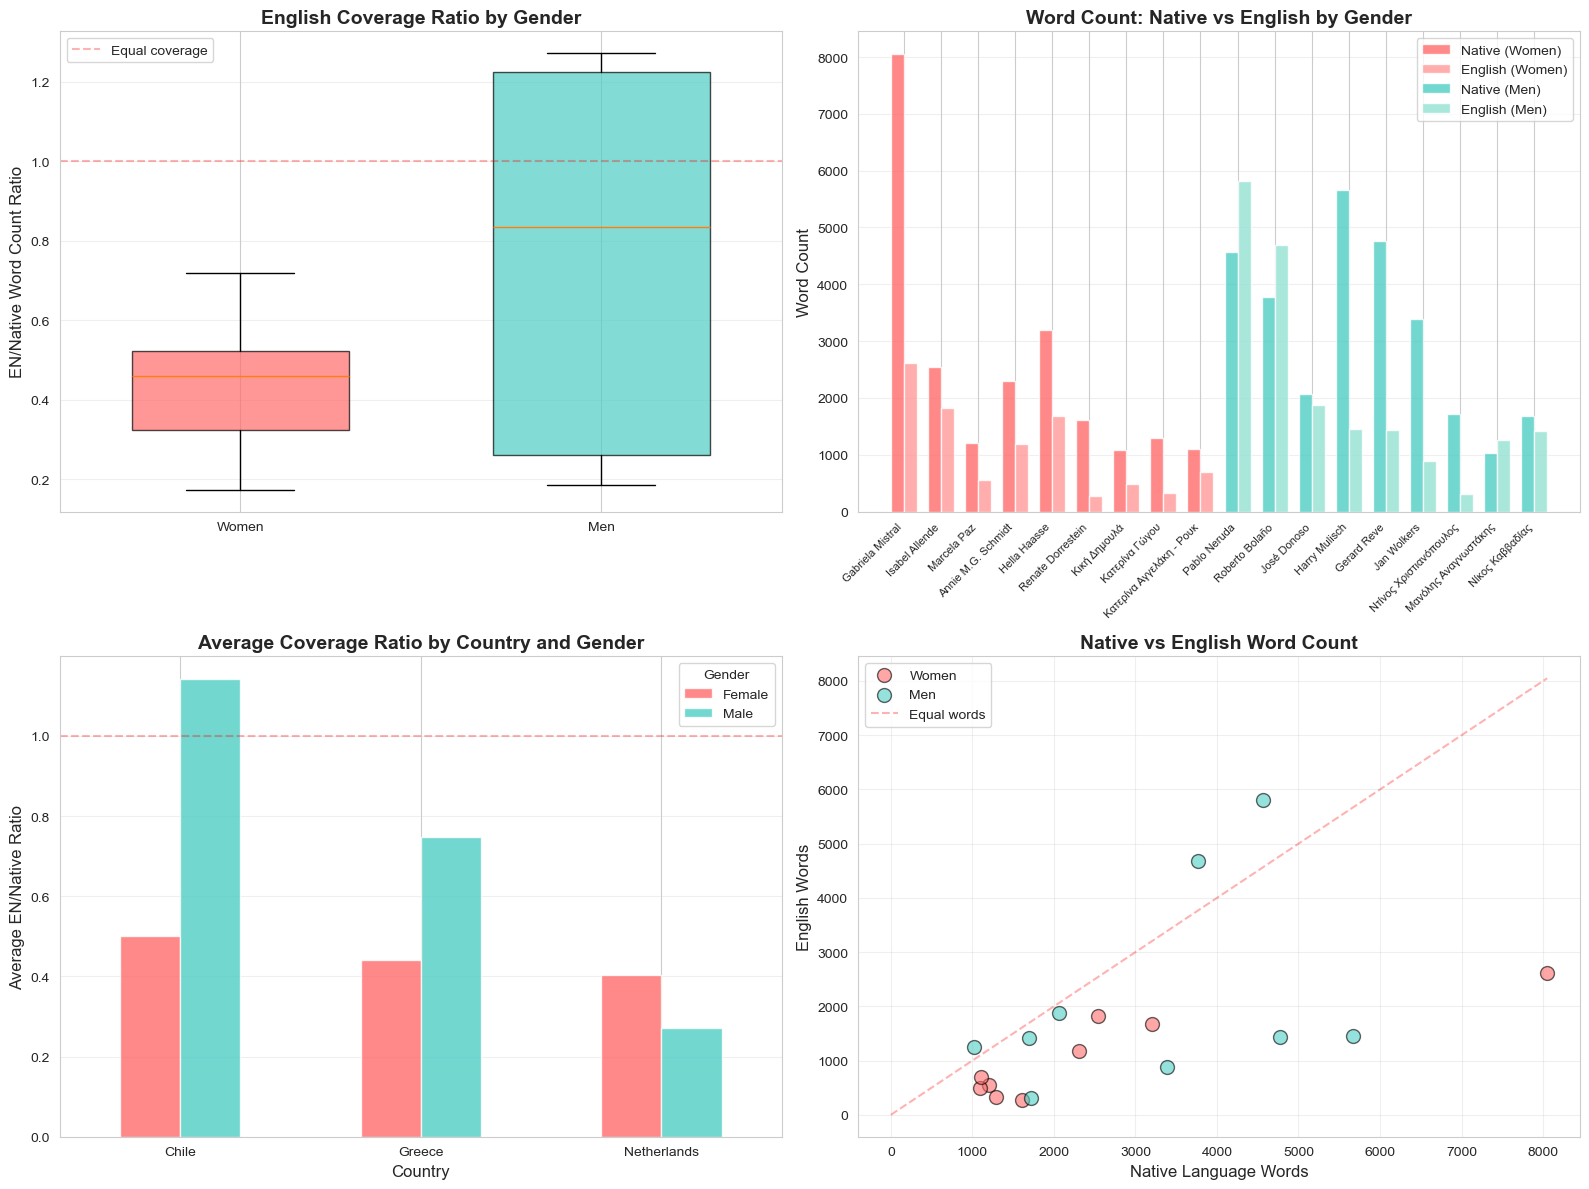

Visualizations created and saved


In [24]:
if PLOTTING_AVAILABLE:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: EN/Native Ratio by Gender
    ax1 = axes[0, 0]
    women_ratios = women_df['Ratio_EN_Native']
    men_ratios = men_df['Ratio_EN_Native']
    
    positions = [1, 2]
    box_data = [women_ratios, men_ratios]
    bp = ax1.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                      labels=['Women', 'Men'])
    
    for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax1.set_ylabel('EN/Native Word Count Ratio', fontsize=12)
    ax1.set_title('English Coverage Ratio by Gender', fontsize=14, fontweight='bold')
    ax1.axhline(y=1, color='red', linestyle='--', alpha=0.3, label='Equal coverage')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Plot 2: Word Count Comparison
    ax2 = axes[0, 1]
    x = np.arange(len(df))
    width = 0.35
    
    women_mask = df['Gender'] == 'Female'
    men_mask = df['Gender'] == 'Male'
    
    ax2.bar(x[women_mask] - width/2, df[women_mask]['Words_Native'], width, 
            label='Native (Women)', alpha=0.8, color='#FF6B6B')
    ax2.bar(x[women_mask] + width/2, df[women_mask]['Words_English'], width, 
            label='English (Women)', alpha=0.8, color='#FF9999')
    ax2.bar(x[men_mask] - width/2, df[men_mask]['Words_Native'], width, 
            label='Native (Men)', alpha=0.8, color='#4ECDC4')
    ax2.bar(x[men_mask] + width/2, df[men_mask]['Words_English'], width, 
            label='English (Men)', alpha=0.8, color='#95E1D3')
    
    ax2.set_ylabel('Word Count', fontsize=12)
    ax2.set_title('Word Count: Native vs English by Gender', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(df['Name'], rotation=45, ha='right', fontsize=8)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # Plot 3: Average Ratio by Country and Gender
    ax3 = axes[1, 0]
    country_gender_ratios = df.groupby(['Country', 'Gender'])['Ratio_EN_Native'].mean().unstack()
    country_gender_ratios.plot(kind='bar', ax=ax3, color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
    
    ax3.set_ylabel('Average EN/Native Ratio', fontsize=12)
    ax3.set_title('Average Coverage Ratio by Country and Gender', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Country', fontsize=12)
    ax3.legend(title='Gender')
    ax3.axhline(y=1, color='red', linestyle='--', alpha=0.3)
    ax3.grid(axis='y', alpha=0.3)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=0)
    
    # Plot 4: Scatter - Native vs English Words
    ax4 = axes[1, 1]
    
    women_data = df[df['Gender'] == 'Female']
    men_data = df[df['Gender'] == 'Male']
    
    ax4.scatter(women_data['Words_Native'], women_data['Words_English'], 
               s=100, alpha=0.6, c='#FF6B6B', label='Women', edgecolors='black', linewidth=1)
    ax4.scatter(men_data['Words_Native'], men_data['Words_English'], 
               s=100, alpha=0.6, c='#4ECDC4', label='Men', edgecolors='black', linewidth=1)
    
    max_words = max(df['Words_Native'].max(), df['Words_English'].max())
    ax4.plot([0, max_words], [0, max_words], 'r--', alpha=0.3, label='Equal words')
    
    ax4.set_xlabel('Native Language Words', fontsize=12)
    ax4.set_ylabel('English Words', fontsize=12)
    ax4.set_title('Native vs English Word Count', fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    plt.savefig(f'gender_comparison_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Visualizations created and saved")
else:
    print("Skipping visualizations (matplotlib not available)")

## 11. Export Results

In [25]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Export full data
csv_file = f'wikipedia_gender_analysis_{timestamp}.csv'
df.to_csv(csv_file, index=False, encoding='utf-8')
print(f" Full data exported: {csv_file}")

# Export comparison summary
comparison_file = f'gender_comparison_summary_{timestamp}.csv'
comparison_df.to_csv(comparison_file, index=False, encoding='utf-8')
print(f" Comparison summary exported: {comparison_file}")

# Export to JSON
json_file = f'wikipedia_gender_analysis_{timestamp}.json'
with open(json_file, 'w', encoding='utf-8') as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False)
print(f" JSON data exported: {json_file}")

print("\n All exports complete")

 Full data exported: wikipedia_gender_analysis_20260116_124615.csv
 Comparison summary exported: gender_comparison_summary_20260116_124615.csv
 JSON data exported: wikipedia_gender_analysis_20260116_124615.json

 All exports complete


## 12. Final Summary & Conclusions

In [26]:
print(" FINAL RESEARCH SUMMARY")


print(f"\n Sample Size:")
print(f"  • Total writers: {len(df)}")
print(f"  • Women: {len(women_df)}")
print(f"  • Men: {len(men_df)}")
print(f"  • Countries: {', '.join(df['Country'].unique())}")

print(f"\n Key Findings:")

women_ratio = women_df['Ratio_EN_Native'].mean()
men_ratio = men_df['Ratio_EN_Native'].mean()
ratio_diff = women_ratio - men_ratio

print(f"\n1. EN/Native Coverage Ratio:")
print(f"   Women average: {women_ratio:.3f}x")
print(f"   Men average: {men_ratio:.3f}x")
print(f"   Difference: {ratio_diff:+.3f}x")

if abs(ratio_diff) < 0.05:
    print(f"   → SIMILAR coverage between genders")
elif ratio_diff < 0:
    print(f"   → Women receive LESS English coverage (potential bias)")
else:
    print(f"   → Women receive MORE English coverage")

women_words = women_df['Words_English'].mean()
men_words = men_df['Words_English'].mean()
words_diff = women_words - men_words

print(f"\n2. English Article Length:")
print(f"   Women average: {women_words:,.0f} words")
print(f"   Men average: {men_words:,.0f} words")
print(f"   Difference: {words_diff:+,.0f} words ({(words_diff/men_words*100):+.1f}%)")

print(f"\n3. By Country:")
for country in df['Country'].unique():
    country_women = df[(df['Country'] == country) & (df['Gender'] == 'Female')]['Ratio_EN_Native'].mean()
    country_men = df[(df['Country'] == country) & (df['Gender'] == 'Male')]['Ratio_EN_Native'].mean()
    country_diff = country_women - country_men
    
    print(f"   {country:15s}: Women {country_women:.3f}x | Men {country_men:.3f}x | Diff {country_diff:+.3f}x")

print(f"\n Files Created:")
print(f"   • CSV data file")
print(f"   • Comparison summary")
print(f"   • JSON data")
print(f"   • Visualization charts")

print(f"\n Analysis complete")

 FINAL RESEARCH SUMMARY

 Sample Size:
  • Total writers: 18
  • Women: 9
  • Men: 9
  • Countries: Chile, Netherlands, Greece

 Key Findings:

1. EN/Native Coverage Ratio:
   Women average: 0.449x
   Men average: 0.721x
   Difference: -0.272x
   → Women receive LESS English coverage (potential bias)

2. English Article Length:
   Women average: 1,070 words
   Men average: 2,124 words
   Difference: -1,054 words (-49.6%)

3. By Country:
   Chile          : Women 0.501x | Men 1.141x | Diff -0.641x
   Netherlands    : Women 0.404x | Men 0.272x | Diff +0.132x
   Greece         : Women 0.441x | Men 0.748x | Diff -0.307x

 Files Created:
   • CSV data file
   • Comparison summary
   • JSON data
   • Visualization charts

 Analysis complete


## Next Steps

1. Review the statistical significance results
2. Examine country-specific patterns
3. Investigate individual outliers
4. Consider qualitative content analysis
5. Prepare final research report

## Research Questions Addressed

Do female writers receive different Wikipedia coverage than male writers?

Are there systematic patterns across countries?

Further investigation: Do differences exist in documentation quality (not just quantity)?
